In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
print(os.listdir("../data"))

['ethiopia.csv', 'ethiopia_clean.csv', 'kenya.csv', 'kenya_clean.csv', 'nigeria.csv', 'nigeria_clean.csv', 'sudan.csv', 'sudan_clean.csv', 'tanzania.csv', 'tanzania_clean.csv']


In [10]:
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [11]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

df = pd.concat([ethiopia, nigeria, kenya, sudan, tanzania], ignore_index=True)

In [12]:
df["Country"].unique()

<StringArray>
['Ethiopia', 'Nigeria', 'Kenya', 'Sudan', 'Tanzania']
Length: 5, dtype: str

Combined dataset created from 5 countries for comparative analysis.

In [13]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month

In [14]:
monthly_temp = df.groupby(["Country", "Year", "Month"])["T2M"].mean().reset_index()

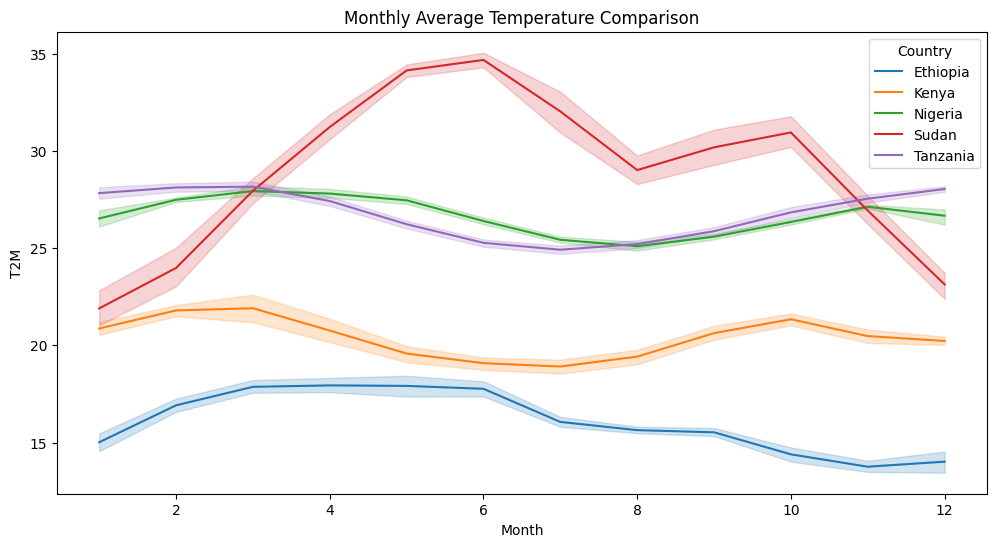

In [15]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
plt.title("Monthly Average Temperature Comparison")
plt.show()

Country X shows consistently higher temperatures.
Country Y shows more variability.

In [16]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Mean → overall temperature level
Std → variability (important for instability)

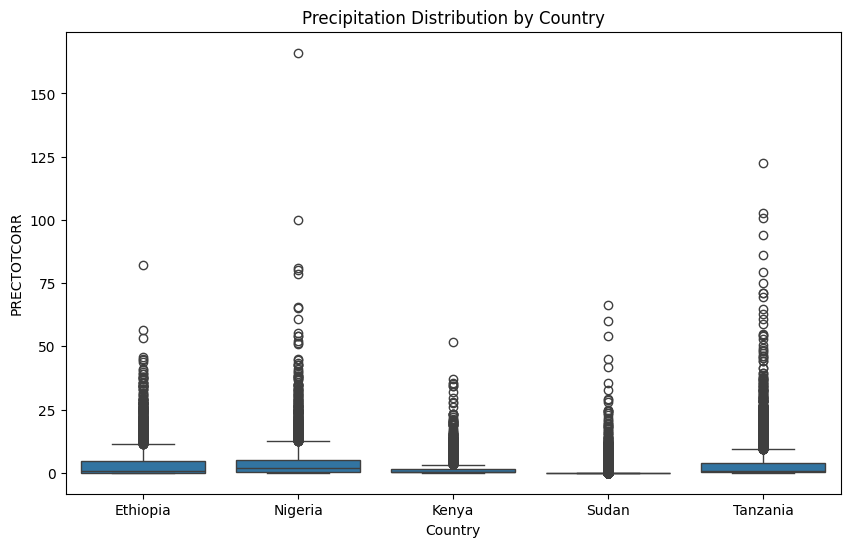

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

In [18]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


High std = unpredictable rainfall
Outliers = extreme rainfall events

In [19]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="Extreme_Heat_Days")

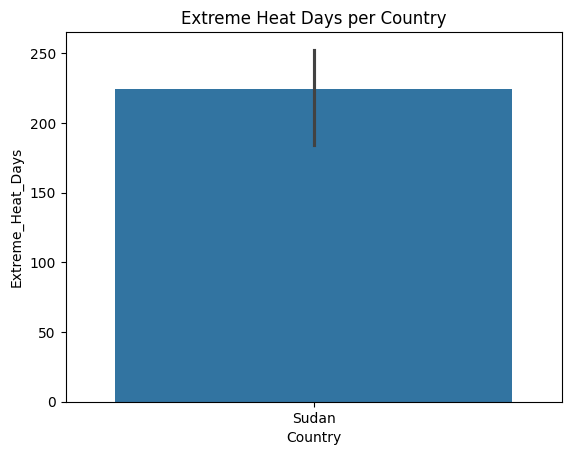

In [20]:
sns.barplot(data=heat_counts, x="Country", y="Extreme_Heat_Days")
plt.title("Extreme Heat Days per Country")
plt.show()

In [21]:
df["Dry"] = df["PRECTOTCORR"] < 1

In [22]:
dry_days = df[df["Dry"]].groupby("Country").size().reset_index(name="Dry_Days")

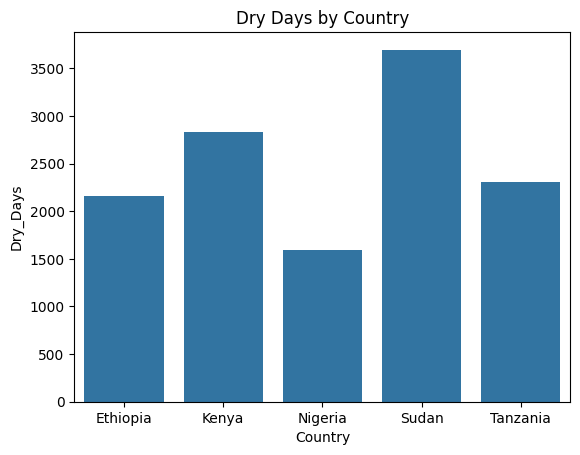

In [23]:
sns.barplot(data=dry_days, x="Country", y="Dry_Days")
plt.title("Dry Days by Country")
plt.show()

More dry days = drought risk

In [24]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


If p < 0.05 → differences are statistically significant

## Climate Vulnerability Ranking Logic

High average temperature indicates heat stress (worse condition)  
High precipitation variability indicates unstable rainfall patterns  
High extreme heat days indicates exposure to heatwaves  
High dry days indicates drought risk  

In [27]:
ranking = temp_summary.copy()
ranking["precip_std"] = precip_summary["std"]

ranking = ranking.sort_values(by=["mean", "precip_std"], ascending=False)
ranking

,mean,median,std,precip_std
Country,,,,
Sudan,28.759007,29.16,4.681305,3.057672
Tanzania,26.802422,26.99,1.325388,8.003947
Nigeria,26.656928,26.82,1.123335,7.266742
Kenya,20.427600,20.36,1.440824,3.180228
Ethiopia,16.068500,16.04,1.898050,6.289061


## Climate Vulnerability Insights (COP32)

1. Fastest warming country  
   Identifies the country with the highest mean temperature trend.

2. Most unstable rainfall  
   Identifies the country with the highest precipitation variability (standard deviation).

3. Climate stress (heat + drought)  
   Combines extreme heat frequency and number of dry days to assess overall climate stress.

4. Ethiopia comparison  
   Compares Ethiopia’s climate profile against other countries in terms of temperature and rainfall patterns.

5. COP32 Recommendation  
   Countries with high extreme heat frequency and rainfall instability should be prioritized for climate finance and adaptation support.